In [1]:
import numpy as np
from tueplots import bundles
import scipy
import matplotlib.pyplot as plt

## setting matplotlib context
from cycler import cycler
from matplotlib.cm import get_cmap
cmap = get_cmap("tab10",8)
palette = [cmap(i) for i in range(8)]
rc = bundles.neurips2024(usetex=False)
rc.update({
    # Set tshe line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})

/var/folders/cx/cy7pq56x7m32_zfmgnslz8cnlnlryt/T/ipykernel_26261/1248219579.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10",8)


In [ ]:
np.random.seed(0)

N = 10000
N_train = 5000
d = 2500   
sigma = 1.0
alpha = 0.01
eps = 1e-12
M = 5000

# n-d Gaussian targets: shape (N, d)
X = np.random.normal(loc=0.0, scale=sigma, size=(N, d))

eta = np.sum(X**2, axis=1) / (
    2.0 * (N_train - 1) * sigma**2
)
eta = np.maximum(eta, eps)

sd = np.sqrt(2.0 * eta)[:, None]

all_llrs_in = np.random.normal(
    loc=+eta[:, None],
    scale=sd,
    size=(N, M),
)

all_llrs_out = np.random.normal(
    loc=-eta[:, None],
    scale=sd, 
    size=(N, M),
)

all_llrs_in_pp = (all_llrs_in + eta[:, None]) / sd
all_llrs_out_pp = (all_llrs_out + eta[:, None]) / sd



In [ ]:
TPRs_pooled, TPRs_pooled_pp, TPRs_px = [],[], []
Ms = [2**i for i in range(3,13)]
for m in Ms:
    llrs_in_pp, llrs_out_pp = all_llrs_in_pp[:,:m], all_llrs_out_pp[:,:m]
    llrs_in, llrs_out = all_llrs_in[:,:m], all_llrs_out[:,:m]

    tau_pool_hat = np.quantile(llrs_out.reshape(-1), q=1 - alpha)
    tpr_pool_hat = (llrs_in.reshape(-1) > tau_pool_hat).mean()

    tau_pool_hat_pp = np.quantile(llrs_out_pp.reshape(-1), q=1 - alpha)
    tpr_pool_hat_pp = (llrs_in_pp.reshape(-1) > tau_pool_hat_pp).mean()

    TPRs_pooled.append(tpr_pool_hat)
    TPRs_pooled_pp.append(tpr_pool_hat_pp)

Ms_px = [2**i for i in range(7,13)]
for m in Ms_px:
    llrs_in_pp, llrs_out_pp = all_llrs_in_pp[:,:m], all_llrs_out_pp[:,:m]
    llrs_in, llrs_out = all_llrs_in[:,:m], all_llrs_out[:,:m]

    tau_i_hat = np.quantile(llrs_out_pp, q=1 - alpha, axis=1)
    tpr_i_avg_hat = (llrs_in_pp > tau_i_hat[:, None]).mean(axis=1).mean()

    TPRs_px.append(tpr_i_avg_hat)

In [11]:
TPRs_px_ana = []
tau_analytical = scipy.stats.norm.ppf(1-alpha)
for m in Ms_px:
    llrs_in, llrs_out = all_llrs_in_pp[:,:m], all_llrs_out_pp[:,:m]
    tau_i_hat = np.quantile(llrs_out, q=1 - alpha, axis=1)
    tpr_i_avg_hat = (llrs_in > tau_analytical).mean(axis=1).mean()
    TPRs_px_ana.append(tpr_i_avg_hat)

In [ ]:
# import pickle
# results = {"TPRs_pooled": TPRs_pooled,
#            "TPRs_pooled_pp": TPRs_pooled_pp,
#            "TPRs_px": TPRs_px,
#            "TPRs_px_ana": TPRs_px_ana}
# with open(f"{d}-d_gaussian.pkl","wb") as f:
#     pickle.dump(results, f)

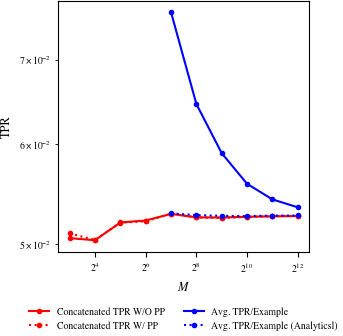

In [ ]:
# from matplotlib.ticker import LogFormatterMathtext
# with plt.rc_context(rc):
#     fig, ax = plt.subplots(1,1)
#     ax.plot(Ms, TPRs_pooled, color="r", marker=".",label="Concatenated TPR W/O PP")
#     ax.plot(Ms, TPRs_pooled_pp, color="r",linestyle=":", marker=".",label=f"Concatenated TPR W/ PP")
#     ax.plot(Ms_px, TPRs_px, color="b",marker=".",label=f"Avg. TPR/Example")
#     ax.plot(Ms_px, TPRs_px_ana, color="b",linestyle=":", marker=".",label=f"Avg. TPR/Example (Analyticsl)")

#     ax.set(xlabel=rf"$M$", ylabel="TPR")
#     ax.set_xscale("log", base=2)
#     ax.set_yscale("log")
#     ax.xaxis.set_major_formatter(LogFormatterMathtext(base=2))
#     ax.xaxis.set_minor_formatter(LogFormatterMathtext(base=2))
#     ax.set_box_aspect(1)
#     ax.legend(
#         loc="lower center",
#         bbox_to_anchor=(0.5, -0.35),
#         ncol=2,
#         frameon=False
#     )
#     # ax.set_title(rf"$N={N},\;N_{{\mathrm{{train}}}}={N_train},\;d={d},\;\alpha={alpha}$")
#     # plt.savefig(f"d={d}_gaussian.pdf")
#     plt.show()

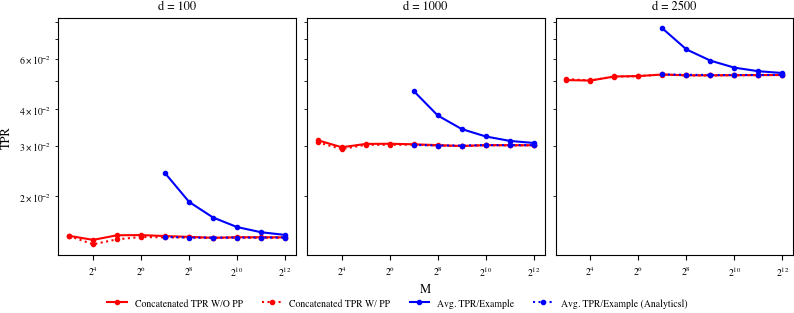

In [4]:
from matplotlib.ticker import LogFormatterMathtext
import pickle
np.random.seed(0)
Ms_px = [2**i for i in range(7,13)]
Ms = [2**i for i in range(3,13)]
N = 10000
N_train = 5000
d = 1000   
sigma = 1.0
alpha = 0.01
eps = 1e-12
M = 5000

d = [100,1000,2500]

with plt.rc_context(rc):
    fig, ax = plt.subplots(1,len(d),sharex="row", sharey="row",figsize=(8,4))
    for i in range(len(d)):
        dim = d[i]
        with open(f"{dim}-d_gaussian.pkl","rb") as f:
            res = pickle.load(f)

        ax[i].plot(Ms, res["TPRs_pooled"], color="r", marker=".",label="Concatenated TPR W/O PP")
        ax[i].plot(Ms, res["TPRs_pooled_pp"], color="r",linestyle=":", marker=".",label=f"Concatenated TPR W/ PP")
        ax[i].plot(Ms_px, res["TPRs_px"], color="b",marker=".",label=f"Avg. TPR/Example")
        ax[i].plot(Ms_px, res["TPRs_px_ana"], color="b",linestyle=":", marker=".",label=f"Avg. TPR/Example (Analyticsl)")   

        ax[i].set_xscale("log", base=2)
        ax[i].set_yscale("log")
        ax[i].xaxis.set_major_formatter(LogFormatterMathtext(base=2))
        ax[i].xaxis.set_minor_formatter(LogFormatterMathtext(base=2))
        ax[i].set_box_aspect(1)
        ax[i].set_title(f"d = {dim}")
    ax[0].set_ylabel("TPR")
    ax[1].set_xlabel("M")
    h,l = ax[0].get_legend_handles_labels()
    fig.legend(h,l,
        loc="lower center",
        bbox_to_anchor=(0.5,0.05),
        ncol=4,
        frameon=False
    )
    # plt.savefig("d_vs_tpr_plot.pdf",bbox_inches="tight")
    plt.show()   